# NLP de comentarios de Youtube

Limpieza, clasificación y análisis temporal de los comentarios sobre inmigración y LGTBI.

In [1]:
#!pip install pysentimiento
#!pip install bertopic
#!pip install sentence-transformers
#!pip install umap-learn
#!pip install hdbscan
#!pip install wordcloud

# Bloque 1 · Configuración del entorno

In [2]:
# ============================
# LIBRERÍAS
# ============================

from pathlib import Path
import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from pysentimiento import create_analyzer

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

from umap import UMAP
from hdbscan import HDBSCAN

from tqdm.auto import tqdm
import sys




c:\Users\herre\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\herre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
# ============================
# RUTAS
# ============================

BASE = Path(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"
)

RUTA_RAW = (
    BASE
    / "01_data"
    / "01_raw"
    / "rrss"
    / "youtube"
)

RUTA_PROCESADOS = (
    BASE
    / "01_data"
    / "02_processed"
    / "rrss"
    / "youtube"
)

RUTA_TABLAS = (
    BASE
    / "03_outputs"
    / "tables"
    / "youtube"
)

RUTA_GRAFICOS = (
    BASE
    / "03_outputs"
    / "figures"
    / "youtube"
)

RUTA_TABLAS.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_GRAFICOS.mkdir(
    parents=True,
    exist_ok=True
)

print("PROCESADOS:", RUTA_PROCESADOS)
print("TABLAS:", RUTA_TABLAS)
print("GRÁFICOS:", RUTA_GRAFICOS)

PROCESADOS: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\rrss\youtube
TABLAS: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\tables\youtube
GRÁFICOS: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\figures\youtube


# Bloque 2 · Carga y preparación de los datos

In [5]:
# ============================
# CARGA DE DATOS
# ============================

comentarios = pd.read_csv(
    RUTA_PROCESADOS / "youtube_comentarios_limpio.csv"
)

print(f"Número de comentarios: {len(comentarios):,}")
comentarios.head()

Número de comentarios: 49,287


,video_id,autor,fecha,likes,texto,titulo_video,canal,fecha_video,año_video,tema
0,jTM-ndTRrtE,@lisifarinas5725,2026-04-19 20:41:35+00:00,0,Pobrecito! Dios lo bendiga mucho ❤❤,"Henry, un inmigrante nigeriano y homosexual, c...",laSexta Noticias,2015-07-17 19:03:29+00:00,2015,inmigracion
1,jTM-ndTRrtE,@lupus-o2p,2025-08-06 12:01:25+00:00,1,Qué triste. Es un ser humano.,"Henry, un inmigrante nigeriano y homosexual, c...",laSexta Noticias,2015-07-17 19:03:29+00:00,2015,inmigracion
2,jTM-ndTRrtE,@yeirihernandez6108,2018-07-20 22:36:45+00:00,1,Que fuerte que pena con este chico,"Henry, un inmigrante nigeriano y homosexual, c...",laSexta Noticias,2015-07-17 19:03:29+00:00,2015,inmigracion
3,jTM-ndTRrtE,@davidsanchez1148,2019-07-13 13:17:52+00:00,1,Pobrecito,"Henry, un inmigrante nigeriano y homosexual, c...",laSexta Noticias,2015-07-17 19:03:29+00:00,2015,inmigracion
4,jTM-ndTRrtE,@blackgoku3788,2022-07-04 19:59:44+00:00,0,Todos los países tienen que a estar la homosex...,"Henry, un inmigrante nigeriano y homosexual, c...",laSexta Noticias,2015-07-17 19:03:29+00:00,2015,inmigracion


In [6]:
comentarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   video_id      49287 non-null  object
 1   autor         49287 non-null  object
 2   fecha         49287 non-null  object
 3   likes         49287 non-null  int64 
 4   texto         49287 non-null  object
 5   titulo_video  49287 non-null  object
 6   canal         49287 non-null  object
 7   fecha_video   49287 non-null  object
 8   año_video     49287 non-null  int64 
 9   tema          49287 non-null  object
dtypes: int64(2), object(8)
memory usage: 3.8+ MB


In [7]:
# ============================
# PREPARACIÓN DEL TEXTO
# ============================

comentarios["texto_original"] = comentarios["texto"]

comentarios["texto_minusculas"] = (
    comentarios["texto_original"]
    .fillna("")
    .str.lower()
)

comentarios["texto_analisis"] = comentarios["texto_minusculas"]

In [8]:
comentarios[
    [
        "texto_original",
        "texto_minusculas",
        "texto_analisis"
    ]
].head()

,texto_original,texto_minusculas,texto_analisis
0,Pobrecito! Dios lo bendiga mucho ❤❤,pobrecito! dios lo bendiga mucho ❤❤,pobrecito! dios lo bendiga mucho ❤❤
1,Qué triste. Es un ser humano.,qué triste. es un ser humano.,qué triste. es un ser humano.
2,Que fuerte que pena con este chico,que fuerte que pena con este chico,que fuerte que pena con este chico
3,Pobrecito,pobrecito,pobrecito
4,Todos los países tienen que a estar la homosex...,todos los países tienen que a estar la homosex...,todos los países tienen que a estar la homosex...


In [9]:
# ============================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================

print(f"Comentarios: {len(comentarios):,}")
print(f"Vídeos: {comentarios['video_id'].nunique():,}")
print(f"Autores: {comentarios['autor'].nunique():,}")
print(f"Canales: {comentarios['canal'].nunique():,}")

display(comentarios.dtypes)

display(comentarios.isna().sum())

duplicados = comentarios.duplicated().sum()
print(f"Duplicados: {duplicados}")

display(comentarios["tema"].value_counts())

display(comentarios["año_video"].value_counts().sort_index())

Comentarios: 49,287
Vídeos: 365
Autores: 41,641
Canales: 196


video_id            object
autor               object
fecha               object
likes                int64
texto               object
titulo_video        object
canal               object
fecha_video         object
año_video            int64
tema                object
texto_original      object
texto_minusculas    object
texto_analisis      object
dtype: object

video_id            0
autor               0
fecha               0
likes               0
texto               0
titulo_video        0
canal               0
fecha_video         0
año_video           0
tema                0
texto_original      0
texto_minusculas    0
texto_analisis      0
dtype: int64

Duplicados: 0


tema
inmigracion    30469
lgtbi          18818
Name: count, dtype: int64

año_video
2015     3574
2016     6838
2019    25901
2023    12974
Name: count, dtype: int64

In [22]:
print("\nVídeos por temática")
print(
    comentarios.groupby("tema")["video_id"]
    .nunique()
)

print("\nComentarios por temática")
print(
    comentarios["tema"]
    .value_counts()
)


Vídeos por temática
tema
inmigracion    229
lgtbi          136
Name: video_id, dtype: int64

Comentarios por temática
tema
inmigracion    30469
lgtbi          18818
Name: count, dtype: int64


In [10]:
# ============================
# LIMPIEZA PARA ANÁLISIS LÉXICO
# ============================

stopwords_es = set(stopwords.words("spanish"))

stopwords_extra = {
    "más", "si", "no", "ni", "ya",
    "ser", "estar", "hacer", "hay",
    "puede", "pueden", "tiene",
    "así", "aquí", "también",
    "solo", "todo", "eso",
    "gente", "vez", "pues", "hace", "ver", "mismo", "bien",
    "ahora", "personas", "parece", "menos",
    "creo", "decir", "años", "mas", "tener",
    "cosas", "claro", "mejor", "hecho",
    "igual", "luego", "siempre", "dos",
    "van", "parte", "nadie", "tan",
    "caso", "dice", "alguien", "cosa",
    "cada", "noticia", "verdad", "aunque",
    "dicho", "cualquier", "ejemplo",
    "persona", "personas", "día", "todas", "toda",
    "bueno", "hombre", "puedes", "vamos",
    "tipo", "cierto", "digo", "tiempo",
    "sido", "seguro", "veo", "etc",
    "forma", "tema", "entonces", "cómo",
    "además", "cuenta", "ahí", "sólo",
    "comentario", "dices", "tal"
}

stopwords_totales = stopwords_es.union(stopwords_extra)


def limpiar_texto_lexico(texto):
    texto = str(texto).lower()

    # Eliminar URLs
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)

    # Eliminar códigos de Menéame como {lol}
    texto = re.sub(r"\{[^}]+\}", " ", texto)

    # Eliminar referencias a comentarios: #1, #25, etc.
    texto = re.sub(r"#\d+", " ", texto)

    # Conservar únicamente letras y espacios
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)

    # Eliminar stopwords y palabras muy cortas
    palabras = [
        palabra
        for palabra in texto.split()
        if palabra not in stopwords_totales
        and len(palabra) > 2
    ]

    return " ".join(palabras)


comentarios["texto_lexico"] = comentarios["texto_analisis"].apply(
    limpiar_texto_lexico
)

display(
    comentarios[
        ["texto_analisis", "texto_lexico"]
    ].head()
)

,texto_analisis,texto_lexico
0,pobrecito! dios lo bendiga mucho ❤❤,pobrecito dios bendiga
1,qué triste. es un ser humano.,triste humano
2,que fuerte que pena con este chico,fuerte pena chico
3,pobrecito,pobrecito
4,todos los países tienen que a estar la homosex...,países homosexualidad


# Bloque 3 · Análisis exploratorio del texto

In [11]:
# ============================
# FRECUENCIA DE PALABRAS
# ============================

texto_completo = " ".join(
    comentarios["texto_lexico"].dropna()
)

frecuencia = pd.DataFrame(
    Counter(texto_completo.split()).most_common(50),
    columns=["palabra", "frecuencia"]
)

display(frecuencia)

frecuencia.to_csv(
    RUTA_TABLAS / "01_frecuencia_palabras.csv",
    index=False
)

,palabra,frecuencia
0,españa,6678
1,vox,4923
2,viva,3058
3,dios,2560
4,españoles,2191
5,país,2088
6,abascal,1947
7,gracias,1568
8,vida,1429
9,the,1276


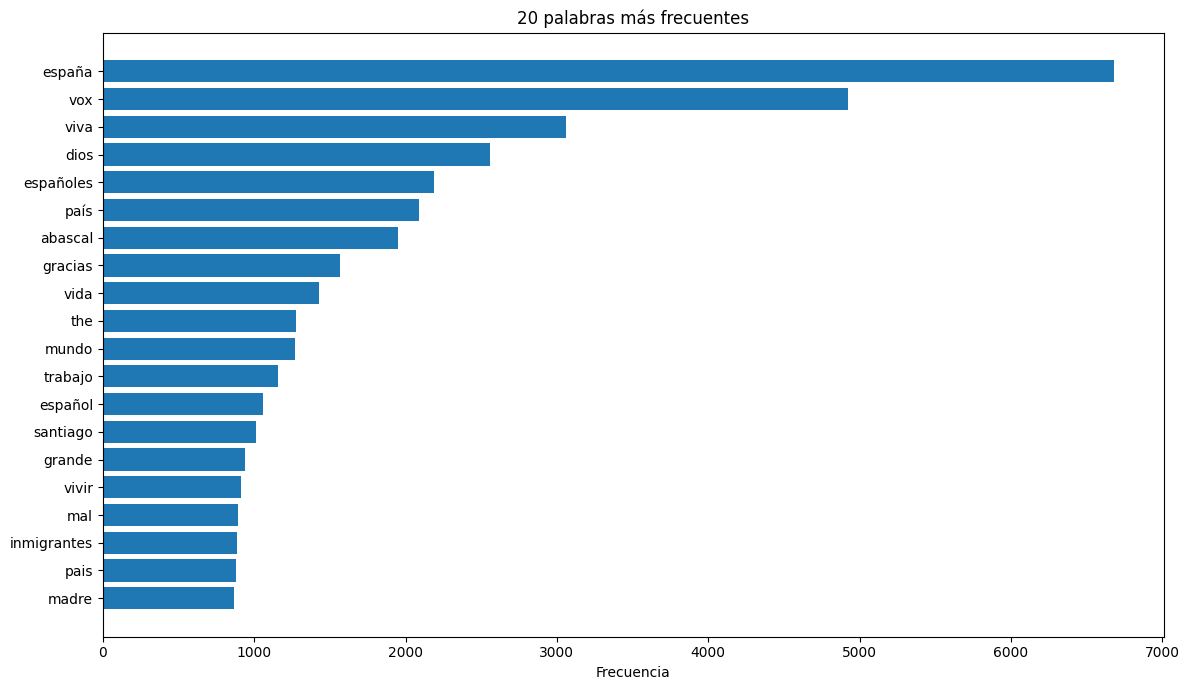

In [12]:
# ============================
# TOP 20 PALABRAS MÁS FRECUENTES
# ============================

top20 = frecuencia.head(20)

plt.figure(figsize=(12, 7))

plt.barh(
    top20["palabra"][::-1],
    top20["frecuencia"][::-1]
)

plt.title("20 palabras más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "01_top20_palabras.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 4 · Aplicación del diccionario de RRSS

In [13]:
# ============================
# AÑADIR RUTA DEL PROYECTO
# ============================

RUTA_DICCIONARIOS = (
    BASE
    / "scripts"
    / "diccionarios"
)

if str(RUTA_DICCIONARIOS) not in sys.path:
    sys.path.append(str(RUTA_DICCIONARIOS))

In [14]:
# ============================
# IMPORTAR DICCIONARIO RRSS
# ============================

from diccionario_rrss import analizar_comentario_rrss

print("Diccionario cargado correctamente.")

Diccionario cargado correctamente.


In [15]:
# ============================
# ANÁLISIS DEL DICCIONARIO
# ============================

resultado = (
    comentarios["texto_lexico"]
    .apply(analizar_comentario_rrss)
    .apply(pd.Series)
)

comentarios = pd.concat(
    [comentarios, resultado],
    axis=1
)

print("Columnas añadidas:")
print(resultado.columns.tolist())

Columnas añadidas:
['nivel_xenofobia_rrss', 'nivel_lgtbifobia_rrss', 'terminos_xenofobia_rrss', 'terminos_lgtbifobia_rrss', 'count_xeno_neutro_rrss', 'count_xeno_conflicto_rrss', 'count_xeno_hostilidad_rrss', 'count_xeno_violencia_rrss', 'count_lgtbi_neutro_rrss', 'count_lgtbi_conflicto_rrss', 'count_lgtbi_hostilidad_rrss', 'count_lgtbi_violencia_rrss']


In [16]:
# ============================
# COMPROBACIÓN
# ============================

display(
    comentarios[
        [
            "texto_lexico",
            "nivel_xenofobia_rrss",
            "nivel_lgtbifobia_rrss"
        ]
    ].sample(15, random_state=42)
)

,texto_lexico,nivel_xenofobia_rrss,nivel_lgtbifobia_rrss
18998,adelante españa viva muerta quieren viva vox v...,sin_mencion,sin_mencion
22400,gracias cheikh vengo diciendo francia fué peli...,sin_mencion,sin_mencion
12591,escuchado misma melodia tonos tambien pasa pue...,sin_mencion,sin_mencion
45045,,sin_mencion,sin_mencion
49024,,sin_mencion,sin_mencion
27524,happy new year call selfish but hope gig berli...,sin_mencion,sin_mencion
16177,ojalá gobierne dia españa,sin_mencion,sin_mencion
41889,paya tren lía alboroto molesta medio tren,sin_mencion,sin_mencion
38860,uooo súper corto,sin_mencion,sin_mencion
43720,hola nikki,sin_mencion,sin_mencion


,nivel,comentarios,porcentaje
0,hostilidad_explicita,185,0.38
1,marco_conflictivo,940,1.91
2,neutro,2538,5.15
3,sin_mencion,45623,92.57
4,violencia_discriminacion,1,0.00


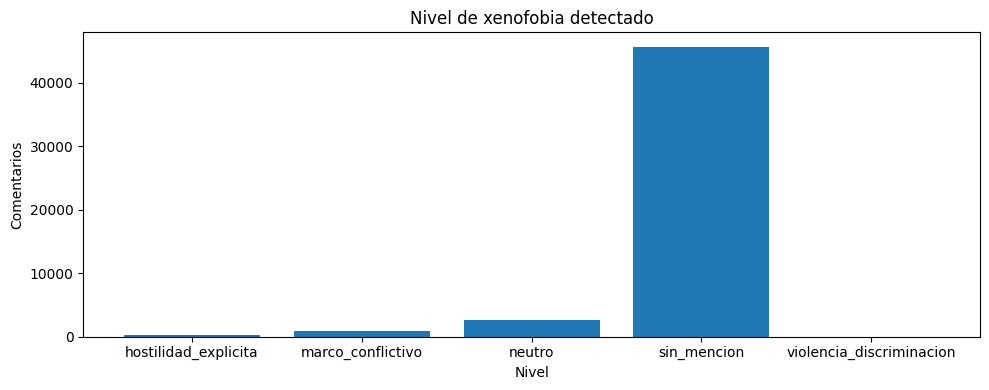

In [17]:
# ============================
# NIVELES DE XENOFOBIA
# ============================

niveles_xeno = (
    comentarios["nivel_xenofobia_rrss"]
    .value_counts()
    .sort_index()
    .reset_index()
)

niveles_xeno.columns = [
    "nivel",
    "comentarios"
]

niveles_xeno["porcentaje"] = (
    niveles_xeno["comentarios"]
    / len(comentarios)
    * 100
).round(2)

display(niveles_xeno)

niveles_xeno.to_csv(
    RUTA_TABLAS / "05_niveles_xenofobia.csv",
    index=False
)

plt.figure(figsize=(10,4))

plt.bar(
    niveles_xeno["nivel"],
    niveles_xeno["comentarios"]
)

plt.title("Nivel de xenofobia detectado")
plt.xlabel("Nivel")
plt.ylabel("Comentarios")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS /
    "05_niveles_xenofobia.png",
    dpi=300
)

plt.show()

,nivel,comentarios,porcentaje
0,hostilidad_explicita,59,0.12
1,marco_conflictivo,99,0.20
2,neutro,2448,4.97
3,sin_mencion,46456,94.26
4,violencia_discriminacion,225,0.46


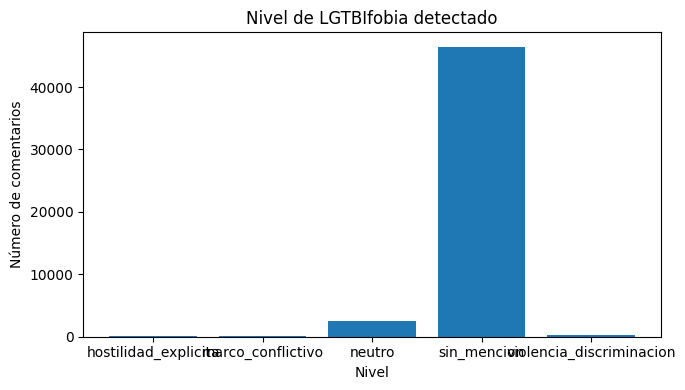

In [18]:
# ============================
# NIVELES DE LGTBIFOBIA
# ============================

niveles_lgtbi = (
    comentarios["nivel_lgtbifobia_rrss"]
    .value_counts()
    .sort_index()
    .reset_index()
)

niveles_lgtbi.columns = [
    "nivel",
    "comentarios"
]

niveles_lgtbi["porcentaje"] = (
    niveles_lgtbi["comentarios"]
    / len(comentarios)
    * 100
).round(2)

display(niveles_lgtbi)

# Guardar tabla
niveles_lgtbi.to_csv(
    RUTA_TABLAS / "06_niveles_lgtbifobia.csv",
    index=False
)

# Gráfico
plt.figure(figsize=(7, 4))

plt.bar(
    niveles_lgtbi["nivel"].astype(str),
    niveles_lgtbi["comentarios"]
)

plt.title("Nivel de LGTBIfobia detectado")
plt.xlabel("Nivel")
plt.ylabel("Número de comentarios")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "06_niveles_lgtbifobia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 5 · Visualización del vocabulario (WordCloud)

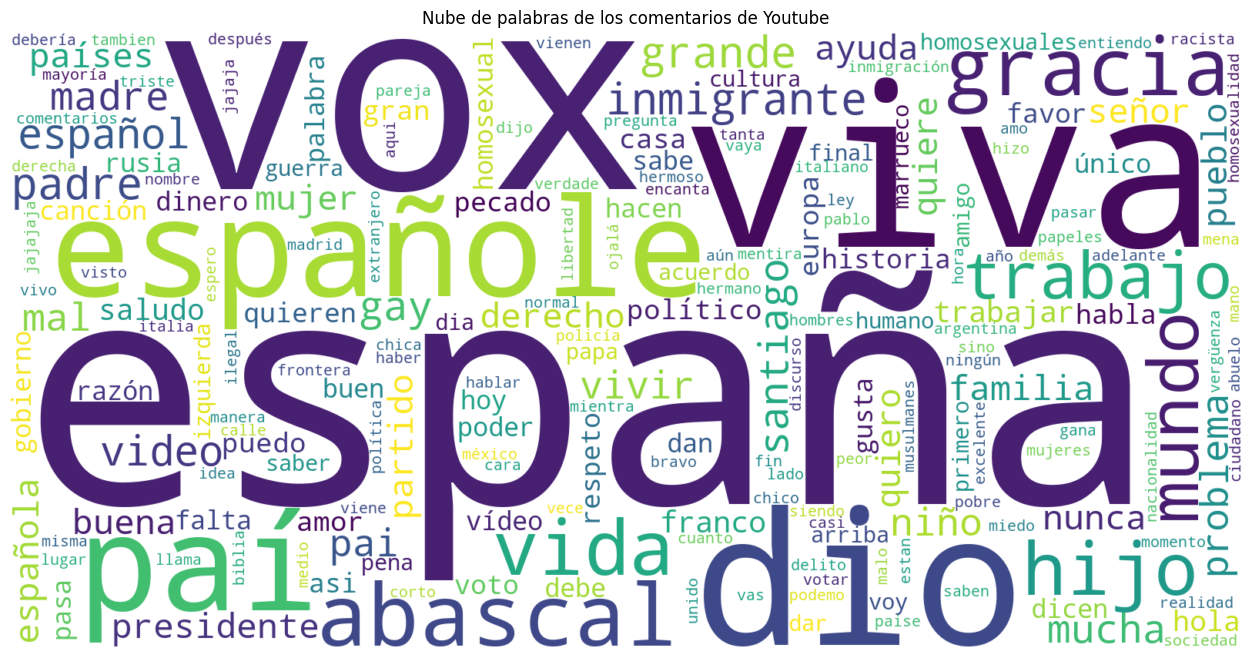

In [19]:
# ============================
# WORDCLOUD
# ============================

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white",
    max_words=200,
    collocations=False,
    random_state=42
).generate(" ".join(comentarios["texto_lexico"]))

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras de los comentarios de Youtube")

plt.savefig(
    RUTA_GRAFICOS / "02_wordcloud.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 6 · Análisis de sentimiento

In [20]:
# ============================
# ANALIZADOR DE SENTIMIENTO
# ============================

analyzer = create_analyzer(
    task="sentiment",
    lang="es"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7168.41it/s]


In [21]:
# ============================
# ANÁLISIS DE SENTIMIENTO
# ============================

from tqdm.auto import tqdm

tqdm.pandas()


comentarios["sentimiento"] = comentarios["texto_analisis"].progress_apply(
    lambda x: analyzer.predict(str(x)).output
)

  0%|          | 32/49287 [00:01<33:15, 24.69it/s] 


KeyboardInterrupt: 

In [ ]:
# ============================
# DISTRIBUCIÓN DEL SENTIMIENTO
# ============================

sentimiento = (
    comentarios["sentimiento"]
    .value_counts()
    .rename_axis("sentimiento")
    .reset_index(name="frecuencia")
)

sentimiento["porcentaje"] = (
    sentimiento["frecuencia"]
    / len(comentarios)
    * 100
).round(2)

display(sentimiento)

sentimiento.to_csv(
    RUTA_TABLAS / "02_sentimiento.csv",
    index=False
)

,sentimiento,frecuencia,porcentaje
0,NEG,20078,40.74
1,NEU,16988,34.47
2,POS,12221,24.80


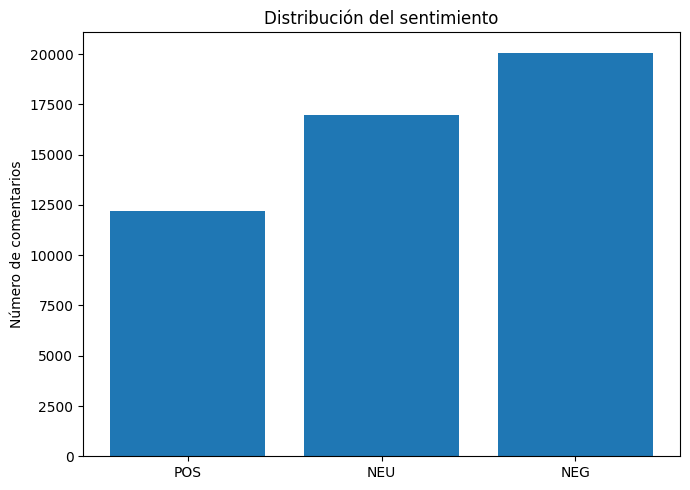

In [ ]:
# ============================
# GRÁFICO DE SENTIMIENTO
# ============================

orden = ["POS", "NEU", "NEG"]

datos = (
    sentimiento
    .set_index("sentimiento")
    .reindex(orden)
    .dropna()
    .reset_index()
)

plt.figure(figsize=(7, 5))

plt.bar(
    datos["sentimiento"],
    datos["frecuencia"]
)

plt.title("Distribución del sentimiento")
plt.xlabel("")
plt.ylabel("Número de comentarios")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "03_sentimiento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
comentarios.to_csv(
    RUTA_PROCESADOS / "youtube_comentarios_analizados.csv",
    index=False
)

In [ ]:
# ============================
# SENTIMIENTO VS XENOFOBIA
# ============================

tabla_xeno = pd.crosstab(
    comentarios["nivel_xenofobia_rrss"],
    comentarios["sentimiento"],
    margins=True
)

display(tabla_xeno)

tabla_xeno.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_xenofobia.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS,All
nivel_xenofobia_rrss,,,,
hostilidad_explicita,125,40,20,185
marco_conflictivo,721,134,85,940
neutro,1702,613,223,2538
sin_mencion,17530,16201,11892,45623
violencia_discriminacion,0,0,1,1
All,20078,16988,12221,49287


In [ ]:
# ============================
# SENTIMIENTO VS LGTBIFOBIA
# ============================

tabla_lgtbi = pd.crosstab(
    comentarios["nivel_lgtbifobia_rrss"],
    comentarios["sentimiento"],
    margins=True
)

display(tabla_lgtbi)

tabla_lgtbi.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_lgtbifobia.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS,All
nivel_lgtbifobia_rrss,,,,
hostilidad_explicita,51,5,3,59
marco_conflictivo,70,22,7,99
neutro,1319,781,348,2448
sin_mencion,18469,16148,11839,46456
violencia_discriminacion,169,32,24,225
All,20078,16988,12221,49287


In [ ]:
# ============================
# PORCENTAJES XENOFOBIA
# ============================

tabla_xeno_pct = (
    pd.crosstab(
        comentarios["nivel_xenofobia_rrss"],
        comentarios["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_xeno_pct)

tabla_xeno_pct.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_xenofobia_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_xenofobia_rrss,,,
hostilidad_explicita,67.57,21.62,10.81
marco_conflictivo,76.70,14.26,9.04
neutro,67.06,24.15,8.79
sin_mencion,38.42,35.51,26.07
violencia_discriminacion,0.00,0.00,100.00


In [ ]:
# ============================
# PORCENTAJES LGTBIFOBIA
# ============================

tabla_lgtbi_pct = (
    pd.crosstab(
        comentarios["nivel_lgtbifobia_rrss"],
        comentarios["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_lgtbi_pct)

tabla_lgtbi_pct.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_lgtbifobia_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_lgtbifobia_rrss,,,
hostilidad_explicita,86.44,8.47,5.08
marco_conflictivo,70.71,22.22,7.07
neutro,53.88,31.90,14.22
sin_mencion,39.76,34.76,25.48
violencia_discriminacion,75.11,14.22,10.67


In [ ]:
# ============================
# CHI-CUADRADO Y V DE CRAMÉR
# XENOFOBIA
# ============================

from scipy.stats import chi2_contingency
import numpy as np

tabla = pd.crosstab(
    comentarios["nivel_xenofobia_rrss"],
    comentarios["sentimiento"]
)

chi2, p, dof, esperados = chi2_contingency(tabla)

n = tabla.to_numpy().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

print("=" * 50)
print("CHI-CUADRADO XENOFOBIA")
print("=" * 50)
print(f"χ² = {chi2:.3f}")
print(f"p-valor = {p:.8f}")
print(f"Grados de libertad = {dof}")
print(f"V de Cramér = {cramers_v:.3f}")

if p < 0.05:
    print("\n✅ Existe una asociación estadísticamente significativa.")
else:
    print("\n❌ No existe una asociación estadísticamente significativa.")

if cramers_v < 0.10:
    fuerza = "muy débil"
elif cramers_v < 0.30:
    fuerza = "débil"
elif cramers_v < 0.50:
    fuerza = "moderada"
else:
    fuerza = "fuerte"

print(f"Fuerza de la asociación: {fuerza}")

CHI-CUADRADO XENOFOBIA
χ² = 1439.552
p-valor = 0.00000000
Grados de libertad = 8
V de Cramér = 0.121

✅ Existe una asociación estadísticamente significativa.
Fuerza de la asociación: débil


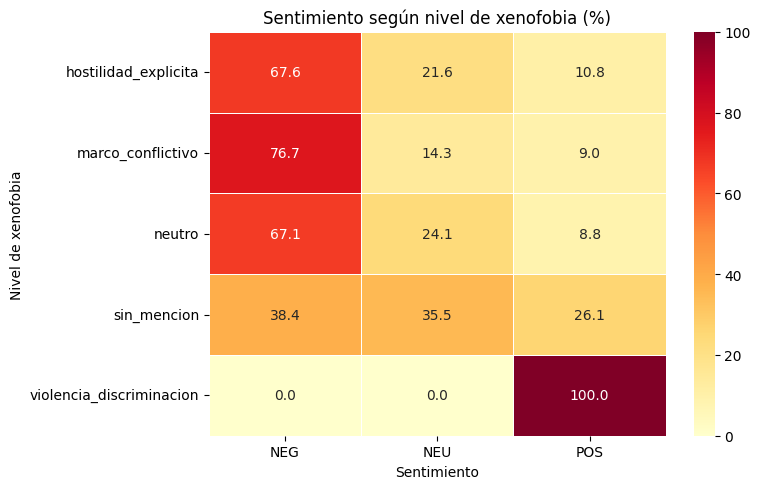

In [ ]:
# ============================
# HEATMAP SENTIMIENTO VS XENOFOBIA
# ============================

import seaborn as sns

plt.figure(figsize=(8, 5))

sns.heatmap(
    tabla_xeno_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Sentimiento según nivel de xenofobia (%)")
plt.xlabel("Sentimiento")
plt.ylabel("Nivel de xenofobia")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "09_heatmap_sentimiento_xenofobia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================
# CHI-CUADRADO Y V DE CRAMÉR
# LGTBIFOBIA
# ============================

tabla = pd.crosstab(
    comentarios["nivel_lgtbifobia_rrss"],
    comentarios["sentimiento"]
)

chi2, p, dof, esperados = chi2_contingency(tabla)

n = tabla.to_numpy().sum()
k = min(tabla.shape)

cramers_v = np.sqrt(
    chi2 / (n * (k - 1))
)

print("=" * 50)
print("CHI-CUADRADO LGTBIFOBIA")
print("=" * 50)
print(f"χ² = {chi2:.3f}")
print(f"p-valor = {p:.8f}")
print(f"Grados de libertad = {dof}")
print(f"V de Cramér = {cramers_v:.3f}")

if p < 0.05:
    print("\n✅ Existe una asociación estadísticamente significativa.")
else:
    print("\n❌ No existe una asociación estadísticamente significativa.")

if cramers_v < 0.10:
    fuerza = "muy débil"
elif cramers_v < 0.30:
    fuerza = "débil"
elif cramers_v < 0.50:
    fuerza = "moderada"
else:
    fuerza = "fuerte"

print(f"Fuerza de la asociación: {fuerza}")

CHI-CUADRADO LGTBIFOBIA
χ² = 439.883
p-valor = 0.00000000
Grados de libertad = 8
V de Cramér = 0.067

✅ Existe una asociación estadísticamente significativa.
Fuerza de la asociación: muy débil


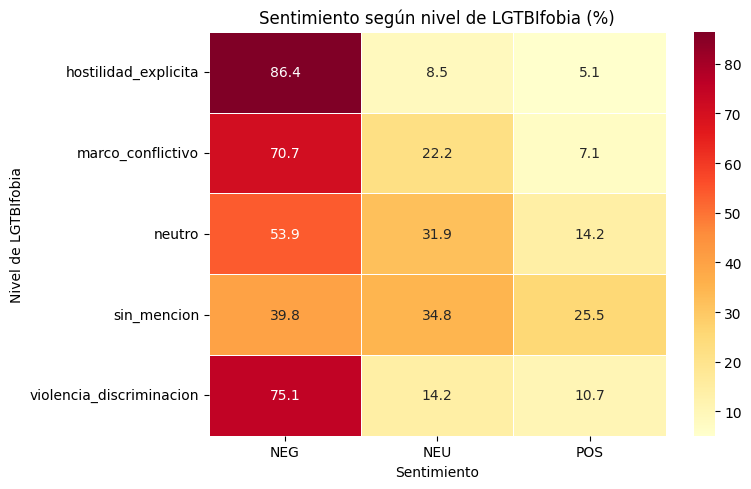

In [ ]:
# ============================
# HEATMAP SENTIMIENTO VS LGTBIFOBIA
# ============================

plt.figure(figsize=(8, 5))

sns.heatmap(
    tabla_lgtbi_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Sentimiento según nivel de LGTBIfobia (%)")
plt.xlabel("Sentimiento")
plt.ylabel("Nivel de LGTBIfobia")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "09_heatmap_sentimiento_lgtbifobia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================
# XENOFOBIA SIN "SIN_MENCION"
# ============================

comentarios_xeno = comentarios[
    comentarios["nivel_xenofobia_rrss"] != "sin_mencion"
].copy()

tabla_xeno_filtrado = (
    pd.crosstab(
        comentarios_xeno["nivel_xenofobia_rrss"],
        comentarios_xeno["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_xeno_filtrado)

tabla_xeno_filtrado.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_xenofobia_sin_mencion_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_xenofobia_rrss,,,
hostilidad_explicita,67.57,21.62,10.81
marco_conflictivo,76.70,14.26,9.04
neutro,67.06,24.15,8.79
violencia_discriminacion,0.00,0.00,100.00


In [ ]:
# ============================
# LGTBIFOBIA SIN "SIN_MENCION"
# ============================

comentarios_lgtbi = comentarios[
    comentarios["nivel_lgtbifobia_rrss"] != "sin_mencion"
].copy()

tabla_lgtbi_filtrado = (
    pd.crosstab(
        comentarios_lgtbi["nivel_lgtbifobia_rrss"],
        comentarios_lgtbi["sentimiento"],
        normalize="index"
    ) * 100
).round(2)

display(tabla_lgtbi_filtrado)

tabla_lgtbi_filtrado.to_csv(
    RUTA_TABLAS / "09_sentimiento_vs_lgtbifobia_sin_mencion_pct.csv",
    encoding="utf-8-sig"
)

sentimiento,NEG,NEU,POS
nivel_lgtbifobia_rrss,,,
hostilidad_explicita,86.44,8.47,5.08
marco_conflictivo,70.71,22.22,7.07
neutro,53.88,31.90,14.22
violencia_discriminacion,75.11,14.22,10.67


In [ ]:
# ============================
# RESUMEN DE PRUEBAS ESTADÍSTICAS
# ============================

def calcular_asociacion(dataframe, variable, nombre):

    tabla = pd.crosstab(
        dataframe[variable],
        dataframe["sentimiento"]
    )

    chi2, p, dof, esperados = chi2_contingency(tabla)

    n = tabla.to_numpy().sum()
    k = min(tabla.shape)

    v_cramer = np.sqrt(
        chi2 / (n * (k - 1))
    )

    if v_cramer < 0.10:
        fuerza = "muy débil"
    elif v_cramer < 0.30:
        fuerza = "débil"
    elif v_cramer < 0.50:
        fuerza = "moderada"
    else:
        fuerza = "fuerte"

    return {
        "comparacion": nombre,
        "n_comentarios": n,
        "chi2": round(chi2, 3),
        "p_valor": p,
        "grados_libertad": dof,
        "v_cramer": round(v_cramer, 3),
        "significativa": "Sí" if p < 0.05 else "No",
        "fuerza_asociacion": fuerza
    }


resultados_estadisticos = [
    calcular_asociacion(
        comentarios,
        "nivel_xenofobia_rrss",
        "Sentimiento vs Xenofobia"
    ),

    calcular_asociacion(
        comentarios_xeno,
        "nivel_xenofobia_rrss",
        "Sentimiento vs Xenofobia (sin sin_mencion)"
    ),

    calcular_asociacion(
        comentarios,
        "nivel_lgtbifobia_rrss",
        "Sentimiento vs LGTBIfobia"
    ),

    calcular_asociacion(
        comentarios_lgtbi,
        "nivel_lgtbifobia_rrss",
        "Sentimiento vs LGTBIfobia (sin sin_mencion)"
    )
]

estadisticos = pd.DataFrame(resultados_estadisticos)

display(estadisticos)

estadisticos.to_csv(
    RUTA_TABLAS / "09_pruebas_estadisticas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Pruebas estadísticas exportadas correctamente.")

,comparacion,n_comentarios,chi2,p_valor,grados_libertad,v_cramer,significativa,fuerza_asociacion
0,Sentimiento vs Xenofobia,49287,1439.552,1.586703e-305,8,0.121,Sí,débil
1,Sentimiento vs Xenofobia (sin sin_mencion),3664,51.504,2.346145e-09,6,0.084,Sí,muy débil
2,Sentimiento vs LGTBIfobia,49287,439.883,5.436835e-90,8,0.067,Sí,muy débil
3,Sentimiento vs LGTBIfobia (sin sin_mencion),2831,70.826,2.768322e-13,6,0.112,Sí,débil


Pruebas estadísticas exportadas correctamente.


# Bloque 7 · Bigramas

,bigrama,frecuencia
0,viva españa,1014
1,viva vox,984
2,santiago abascal,437
3,españa viva,403
4,vox viva,359
5,vox vox,335
6,dios bendiga,227
7,arriba españa,204
8,abascal presidente,198
9,hijos dios,181


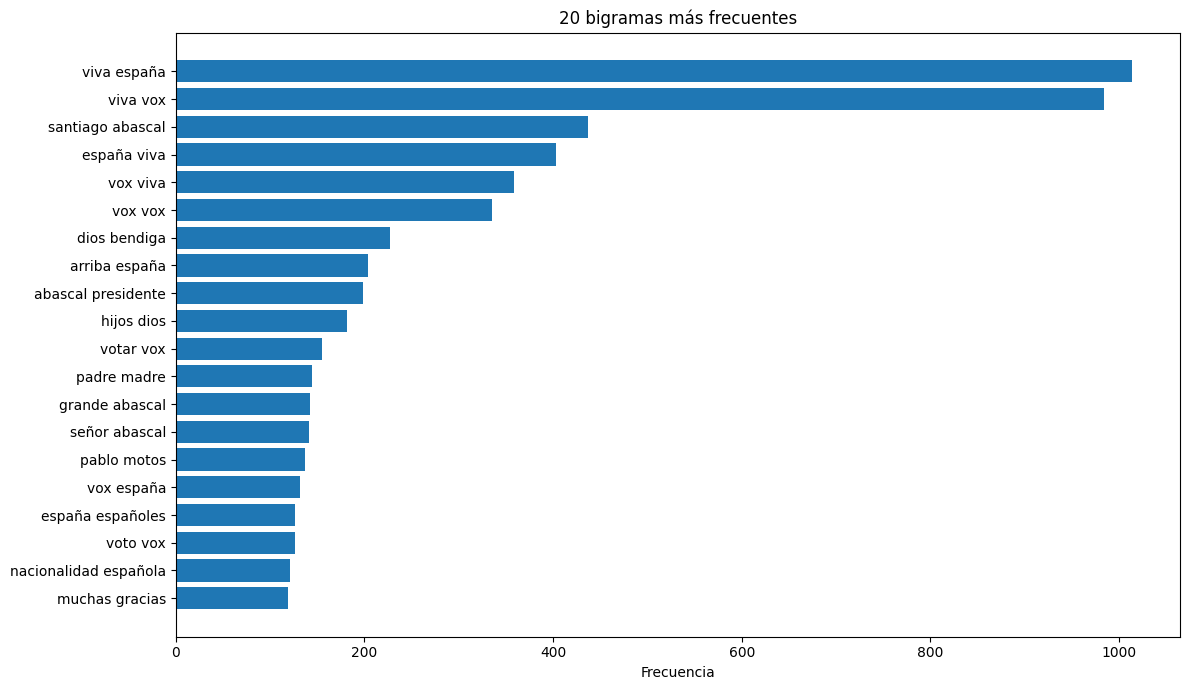

In [ ]:
# ============================
# BIGRAMAS MÁS FRECUENTES
# ============================

from sklearn.feature_extraction.text import CountVectorizer

vectorizador_bigramas = CountVectorizer(
    ngram_range=(2, 2),
    min_df=5
)

matriz_bigramas = vectorizador_bigramas.fit_transform(
    comentarios["texto_lexico"].fillna("")
)

frecuencias_bigramas = matriz_bigramas.sum(axis=0).A1
nombres_bigramas = vectorizador_bigramas.get_feature_names_out()

bigramas = (
    pd.DataFrame({
        "bigrama": nombres_bigramas,
        "frecuencia": frecuencias_bigramas
    })
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(bigramas.head(30))

In [ ]:
# ============================
# EXPORTAR BIGRAMAS
# ============================

bigramas.to_csv(
    RUTA_TABLAS / "10_bigramas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Bigramas exportados correctamente.")

Bigramas exportados correctamente.


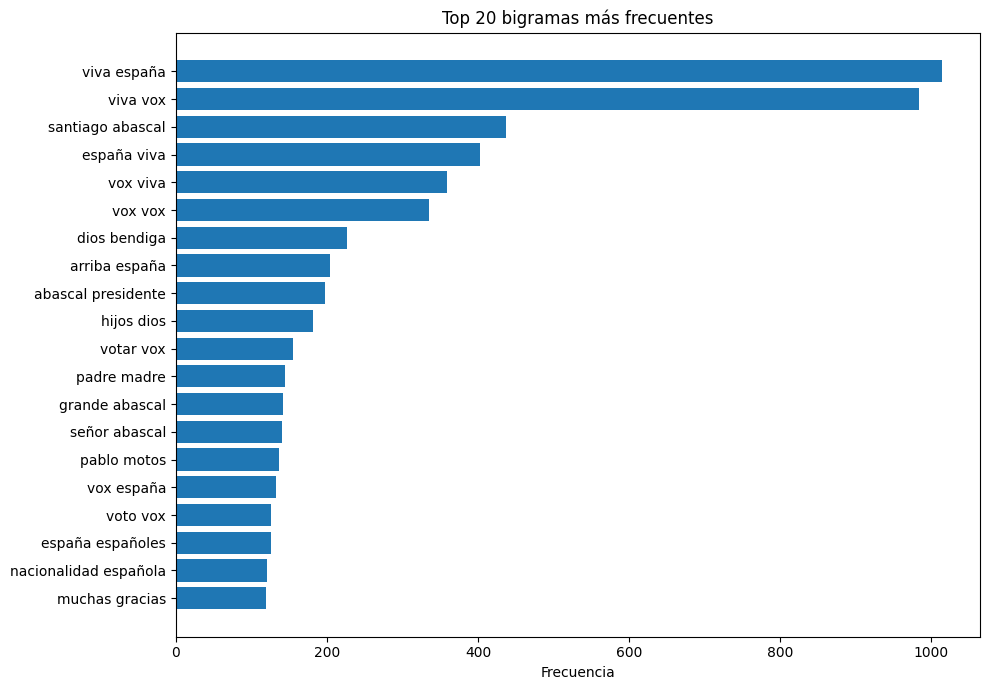

In [ ]:
# ============================
# GRÁFICO TOP 20 BIGRAMAS
# ============================

top20_bigramas = bigramas.head(20).sort_values(
    "frecuencia",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top20_bigramas["bigrama"],
    top20_bigramas["frecuencia"]
)

plt.title("Top 20 bigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "10_top20_bigramas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 8 · Trigramas

In [ ]:
# ============================
# TRIGRAMAS MÁS FRECUENTES
# ============================

from sklearn.feature_extraction.text import CountVectorizer

vectorizador_trigramas = CountVectorizer(
    ngram_range=(3, 3),
    min_df=5
)

matriz_trigramas = vectorizador_trigramas.fit_transform(
    comentarios["texto_lexico"].fillna("")
)

frecuencias_trigramas = matriz_trigramas.sum(axis=0).A1
nombres_trigramas = vectorizador_trigramas.get_feature_names_out()

trigramas = (
    pd.DataFrame({
        "trigrama": nombres_trigramas,
        "frecuencia": frecuencias_trigramas
    })
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(trigramas.head(30))

,trigrama,frecuencia
0,vox viva españa,272
1,viva vox viva,264
2,viva españa viva,260
3,españa viva vox,222
4,vox vox vox,188
5,santiago abascal presidente,57
6,abascal viva vox,49
7,bla bla bla,47
8,heredarán reino dios,39
9,quiero pasar noche,37


In [ ]:
# ============================
# EXPORTAR TRIGRAMAS
# ============================

trigramas.to_csv(
    RUTA_TABLAS / "11_trigramas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Trigramas exportados correctamente.")

Trigramas exportados correctamente.


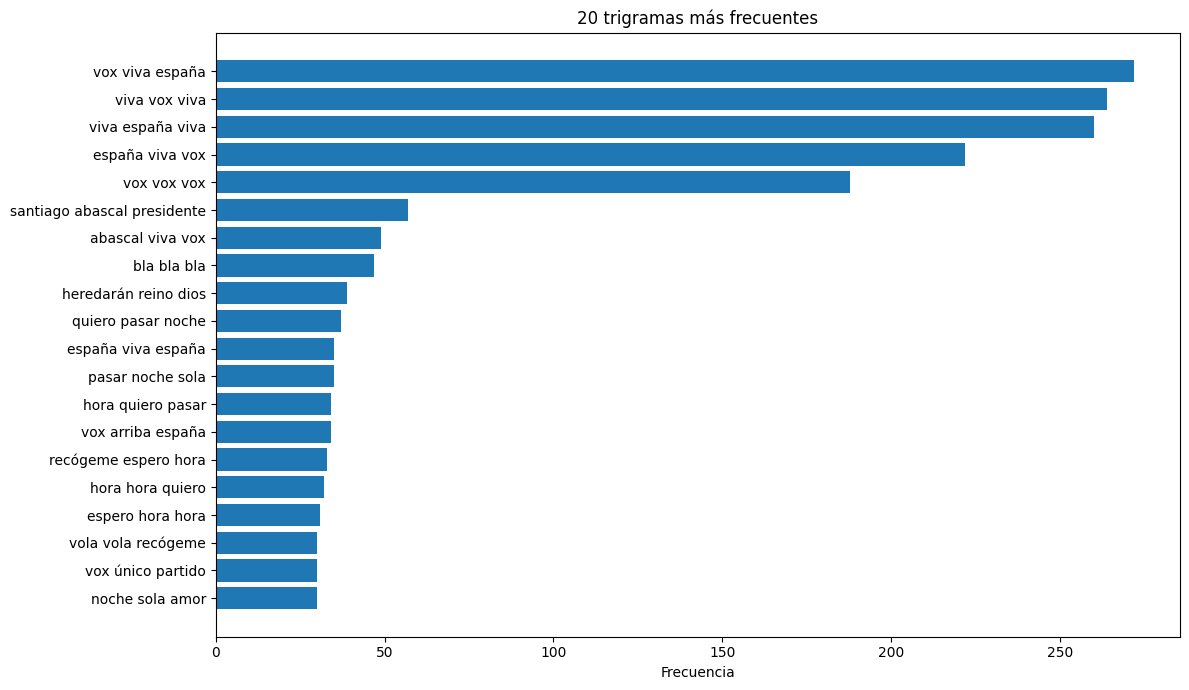

In [ ]:
# ============================
# TOP 20 TRIGRAMAS MÁS FRECUENTES
# ============================

top20 = trigramas.head(20)

plt.figure(figsize=(12, 7))

plt.barh(
    top20["trigrama"][::-1],
    top20["frecuencia"][::-1]
)

plt.title("20 trigramas más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "11_top20_trigramas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 9 · Modelado de temas (BERTopic)

In [ ]:
# ============================
# PREPARAR TEXTOS PARA BERTOPIC
# ============================

documentos = (
    comentarios["texto_analisis"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Eliminar textos vacíos o demasiado cortos
mascara_bertopic = documentos.str.len() >= 20

documentos_bertopic = documentos[mascara_bertopic].tolist()
indices_bertopic = comentarios.index[mascara_bertopic]

print(f"Comentarios totales: {len(comentarios):,}")
print(f"Comentarios utilizados en BERTopic: {len(documentos_bertopic):,}")

Comentarios totales: 49,287
Comentarios utilizados en BERTopic: 42,445


In [ ]:
# ============================
# CONFIGURACIÓN DE BERTOPIC
# ============================

modelo_embeddings = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

modelo_umap = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

modelo_hdbscan = HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

stopwords_bertopic_extra = {
    "lol",
    "grin",
    "troll",
    "https",
    "http",
    "www",
    "net",
    "com",
    "watch",
    "youtube",
    "youtu",
    "youtu be",
    "video",
    "vídeo",
    "gracias",
    "va",
    "da"
}

stopwords_bertopic = stopwords_totales.union(
    stopwords_bertopic_extra
)

vectorizador_bertopic = CountVectorizer(
    stop_words=list(stopwords_bertopic),
    ngram_range=(1, 2),
    min_df=5
)

modelo_bertopic = BERTopic(
    embedding_model=modelo_embeddings,
    umap_model=modelo_umap,
    hdbscan_model=modelo_hdbscan,
    vectorizer_model=vectorizador_bertopic,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

print("Modelo BERTopic configurado correctamente.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5342.17it/s]


Modelo BERTopic configurado correctamente.


In [ ]:
# ============================
# ENTRENAMIENTO DE BERTOPIC
# ============================

topics, probabilities = modelo_bertopic.fit_transform(
    documentos_bertopic
)

print("BERTopic finalizado.")
print(f"Número de documentos procesados: {len(topics):,}")

2026-07-21 10:24:22,831 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 1327/1327 [03:39<00:00,  6.05it/s]
2026-07-21 10:28:02,203 - BERTopic - Embedding - Completed ✓
2026-07-21 10:28:02,203 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-21 10:28:34,059 - BERTopic - Dimensionality - Completed ✓
2026-07-21 10:28:34,060 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-21 10:28:36,143 - BERTopic - Cluster - Completed ✓
2026-07-21 10:28:36,148 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-21 10:28:36,845 - BERTopic - Representation - Completed ✓


BERTopic finalizado.
Número de documentos procesados: 42,445


In [ ]:
# ============================
# RESUMEN DE TEMAS
# ============================

temas = modelo_bertopic.get_topic_info()

display(temas.head(20))

temas.to_csv(
    RUTA_TABLAS / "12_bertopic_temas.csv",
    index=False,
    encoding="utf-8-sig"
)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,17478,-1_españa_vox_viva_españoles,"[españa, vox, viva, españoles, the, país, abas...","[viva vox y viva españa, viva españa y viva vo..."
1,0,1504,0_dios_pecado_biblia_papa,"[dios, pecado, biblia, papa, hijos dios, jesús...","[bueno, eso hay que explicárselo a dios🤷‍♀️, e..."
2,1,1454,1_vox_votar_voto_partido,"[vox, votar, voto, partido, elecciones, políti...",[viva vox viva españa \na votar avox. que boi ...
3,2,1279,2_gay_homosexuales_lgbt_homofobia,"[gay, homosexuales, lgbt, homofobia, gays, hom...","[¿daniel carreño es gay?, orgullosamente gay !..."
4,3,1158,3_ole_españa_abascal_ole ole,"[ole, españa, abascal, ole ole, pablo, vas, sa...",[ole y ole.viva españa mi tierra.que buen bole...
5,4,962,4_inmigrantes_inmigración_ilegal_inmigrante,"[inmigrantes, inmigración, ilegal, inmigrante,...","[hhhhh sin inmigrantes que ?, hombre, el probl..."
6,5,895,5_bla_bla bla_amén_putin,"[bla, bla bla, amén, putin, españa, grande, ay...","[nooooo como q daniel carreon,no es lqbt, gran..."
7,6,775,6_madre_padre_niño_niños,"[madre, padre, niño, niños, padres, padre madr...","[viva me padre y me madre, sí claro que siempr..."
8,7,719,7_canción_cancion_hermosa_bonita,"[canción, cancion, hermosa, bonita, música, so...","[está llegadora la canción., una chulada de ca..."
9,8,670,8_videos_vídeos_buen_encanta,"[videos, vídeos, buen, encanta, this, canal, c...","[ya hay hasta videos de esto, es totalmente su..."


In [ ]:
# ============================
# AÑADIR TOPIC AL DATAFRAME
# ============================

comentarios["topic"] = -1

comentarios.loc[
    indices_bertopic,
    "topic"
] = topics

comentarios["topic"] = comentarios["topic"].astype(int)

comentarios.to_csv(
    RUTA_PROCESADOS / "youtube_comentarios_analizados.csv",
    index=False
)

print("Topics asignados correctamente.")

Topics asignados correctamente.


In [ ]:
# ============================
# DISTRIBUCIÓN DE TEMAS
# ============================

topicos = (
    comentarios["topic"]
    .value_counts()
    .sort_index()
    .reset_index()
)

topicos.columns = [
    "topic",
    "comentarios"
]

display(topicos)

topicos.to_csv(
    RUTA_TABLAS / "12_distribucion_topics.csv",
    index=False,
    encoding="utf-8-sig"
)

,topic,comentarios
0,-1,24320
1,0,1504
2,1,1454
3,2,1279
4,3,1158
...,...,...
90,89,60
91,90,57
92,91,57
93,92,54


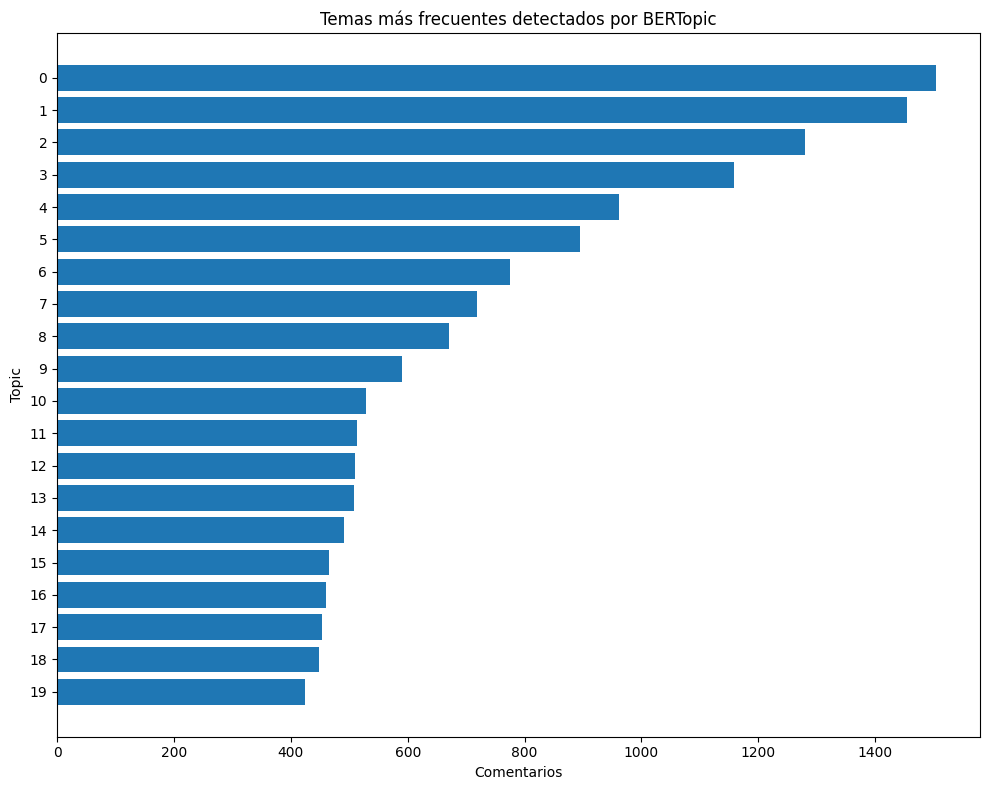

In [ ]:
# ============================
# TOP 20 TEMAS
# ============================

top20 = (
    topicos
    .query("topic != -1")
    .sort_values("comentarios", ascending=False)
    .head(20)
    .sort_values("comentarios")
)

plt.figure(figsize=(10,8))

plt.barh(
    top20["topic"].astype(str),
    top20["comentarios"]
)

plt.title("Temas más frecuentes detectados por BERTopic")
plt.xlabel("Comentarios")
plt.ylabel("Topic")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "12_top_topics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
temas.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,17478,-1_españa_vox_viva_españoles,"[españa, vox, viva, españoles, the, país, abas...","[viva vox y viva españa, viva españa y viva vo..."
1,0,1504,0_dios_pecado_biblia_papa,"[dios, pecado, biblia, papa, hijos dios, jesús...","[bueno, eso hay que explicárselo a dios🤷‍♀️, e..."
2,1,1454,1_vox_votar_voto_partido,"[vox, votar, voto, partido, elecciones, políti...",[viva vox viva españa \na votar avox. que boi ...
3,2,1279,2_gay_homosexuales_lgbt_homofobia,"[gay, homosexuales, lgbt, homofobia, gays, hom...","[¿daniel carreño es gay?, orgullosamente gay !..."
4,3,1158,3_ole_españa_abascal_ole ole,"[ole, españa, abascal, ole ole, pablo, vas, sa...",[ole y ole.viva españa mi tierra.que buen bole...
5,4,962,4_inmigrantes_inmigración_ilegal_inmigrante,"[inmigrantes, inmigración, ilegal, inmigrante,...","[hhhhh sin inmigrantes que ?, hombre, el probl..."
6,5,895,5_bla_bla bla_amén_putin,"[bla, bla bla, amén, putin, españa, grande, ay...","[nooooo como q daniel carreon,no es lqbt, gran..."
7,6,775,6_madre_padre_niño_niños,"[madre, padre, niño, niños, padres, padre madr...","[viva me padre y me madre, sí claro que siempr..."
8,7,719,7_canción_cancion_hermosa_bonita,"[canción, cancion, hermosa, bonita, música, so...","[está llegadora la canción., una chulada de ca..."
9,8,670,8_videos_vídeos_buen_encanta,"[videos, vídeos, buen, encanta, this, canal, c...","[ya hay hasta videos de esto, es totalmente su..."


In [ ]:
# ============================
# RESUMEN DE TOPICS
# ============================

temas = modelo_bertopic.get_topic_info()

temas["Porcentaje"] = (
    temas["Count"]
    / temas["Count"].sum()
    * 100
).round(2)

display(temas)

temas.to_csv(
    RUTA_TABLAS / "12_resumen_topics.csv",
    index=False,
    encoding="utf-8-sig"
)

,Topic,Count,Name,Representation,Representative_Docs,Porcentaje
0,-1,17478,-1_españa_vox_viva_españoles,"[españa, vox, viva, españoles, the, país, abas...","[viva vox y viva españa, viva españa y viva vo...",41.18
1,0,1504,0_dios_pecado_biblia_papa,"[dios, pecado, biblia, papa, hijos dios, jesús...","[bueno, eso hay que explicárselo a dios🤷‍♀️, e...",3.54
2,1,1454,1_vox_votar_voto_partido,"[vox, votar, voto, partido, elecciones, políti...",[viva vox viva españa \na votar avox. que boi ...,3.43
3,2,1279,2_gay_homosexuales_lgbt_homofobia,"[gay, homosexuales, lgbt, homofobia, gays, hom...","[¿daniel carreño es gay?, orgullosamente gay !...",3.01
4,3,1158,3_ole_españa_abascal_ole ole,"[ole, españa, abascal, ole ole, pablo, vas, sa...",[ole y ole.viva españa mi tierra.que buen bole...,2.73
...,...,...,...,...,...,...
90,89,60,89_bandera_banderas_blanco_franquista,"[bandera, banderas, blanco, franquista, papele...",[-tu bandera tiene una chispa\n-ay quítasela q...,0.14
91,90,57,90_pollo_comer pollo_comer_lesbiana,"[pollo, comer pollo, comer, lesbiana, gay, hom...","[hijo: soy gay\n\n""por comer mucho pollo"", soy...",0.13
92,91,57,91_spain_spanish_this_was,"[spain, spanish, this, was, and, of, the, next...","[i am living in chile (1.5 years now), and i h...",0.13
93,92,54,92_historia_story_história_linda,"[historia, story, história, linda, ganas saber...","[amo esta historia..., es una historia muy her...",0.13


In [ ]:
# ============================
# COMENTARIOS REPRESENTATIVOS
# ============================

representativos = []

for topic in temas["Topic"]:

    if topic == -1:
        continue

    docs = modelo_bertopic.get_representative_docs(topic)

    if docs is None:
        continue

    for i, doc in enumerate(docs[:3], start=1):

        representativos.append({
            "topic": topic,
            "ejemplo": i,
            "comentario": doc
        })

representativos = pd.DataFrame(representativos)

display(representativos.head(20))

representativos.to_csv(
    RUTA_TABLAS / "12_comentarios_representativos.csv",
    index=False,
    encoding="utf-8-sig"
)

,topic,ejemplo,comentario
0,0,1,"bueno, eso hay que explicárselo a dios🤷‍♀️"
1,0,2,eso hace que odie a dios
2,0,3,dios no creo adán y a estaban
3,1,1,viva vox viva españa \na votar avox. que boi 🇪🇸
4,1,2,el 10n a votar a vox
5,1,3,10n a votar vox! viva españa!
6,2,1,¿daniel carreño es gay?
7,2,2,orgullosamente gay !!
8,2,3,".\n\n\n\n\n\n\n\n\n\n¿¡como que el ""facilisimo..."
9,3,1,ole y ole.viva españa mi tierra.que buen bolero.


In [ ]:
# ============================
# PALABRAS CLAVE POR TOPIC
# ============================

palabras_topic = []

for topic in temas["Topic"]:

    if topic == -1:
        continue

    palabras = modelo_bertopic.get_topic(topic)

    palabras_topic.append({
        "topic": topic,
        "palabras_clave": ", ".join(
            palabra
            for palabra, _ in palabras[:10]
        )
    })

palabras_topic = pd.DataFrame(palabras_topic)

display(palabras_topic)

palabras_topic.to_csv(
    RUTA_TABLAS / "12_palabras_clave_topics.csv",
    index=False,
    encoding="utf-8-sig"
)

,topic,palabras_clave
0,0,"dios, pecado, biblia, papa, hijos dios, jesús,..."
1,1,"vox, votar, voto, partido, elecciones, polític..."
2,2,"gay, homosexuales, lgbt, homofobia, gays, homo..."
3,3,"ole, españa, abascal, ole ole, pablo, vas, san..."
4,4,"inmigrantes, inmigración, ilegal, inmigrante, ..."
...,...,...
89,89,"bandera, banderas, blanco, franquista, papelet..."
90,90,"pollo, comer pollo, comer, lesbiana, gay, homo..."
91,91,"spain, spanish, this, was, and, of, the, next,..."
92,92,"historia, story, história, linda, ganas saber,..."


In [ ]:
# ============================
# RESUMEN FINAL DE TOPICS
# ============================

resumen_topics = (
    temas[["Topic", "Count", "Porcentaje"]]
    .merge(
        palabras_topic,
        left_on="Topic",
        right_on="topic",
        how="left"
    )
    .drop(columns="topic")
)

display(resumen_topics)

resumen_topics.to_csv(
    RUTA_TABLAS / "12_resumen_final_topics.csv",
    index=False,
    encoding="utf-8-sig"
)

,Topic,Count,Porcentaje,palabras_clave
0,-1,17478,41.18,NaN
1,0,1504,3.54,"dios, pecado, biblia, papa, hijos dios, jesús,..."
2,1,1454,3.43,"vox, votar, voto, partido, elecciones, polític..."
3,2,1279,3.01,"gay, homosexuales, lgbt, homofobia, gays, homo..."
4,3,1158,2.73,"ole, españa, abascal, ole ole, pablo, vas, san..."
...,...,...,...,...
90,89,60,0.14,"bandera, banderas, blanco, franquista, papelet..."
91,90,57,0.13,"pollo, comer pollo, comer, lesbiana, gay, homo..."
92,91,57,0.13,"spain, spanish, this, was, and, of, the, next,..."
93,92,54,0.13,"historia, story, história, linda, ganas saber,..."


In [ ]:
# ============================
# TOP 15 TOPICS PARA ETIQUETAR
# ============================

top15_topics = (
    resumen_topics
    .query("Topic != -1")
    .sort_values("Count", ascending=False)
    .head(15)
)

display(
    top15_topics[
        ["Topic", "Count", "Porcentaje", "palabras_clave"]
    ]
)

,Topic,Count,Porcentaje,palabras_clave
1,0,1504,3.54,"dios, pecado, biblia, papa, hijos dios, jesús,..."
2,1,1454,3.43,"vox, votar, voto, partido, elecciones, polític..."
3,2,1279,3.01,"gay, homosexuales, lgbt, homofobia, gays, homo..."
4,3,1158,2.73,"ole, españa, abascal, ole ole, pablo, vas, san..."
5,4,962,2.27,"inmigrantes, inmigración, ilegal, inmigrante, ..."
6,5,895,2.11,"bla, bla bla, amén, putin, españa, grande, ay,..."
7,6,775,1.83,"madre, padre, niño, niños, padres, padre madre..."
8,7,719,1.69,"canción, cancion, hermosa, bonita, música, son..."
9,8,670,1.58,"videos, vídeos, buen, encanta, this, canal, cl..."
10,9,590,1.39,"español, españoles, spanish, española, she, es..."


In [ ]:
# ============================
# PREPARAR TOP TEMAS INTERPRETABLES
# ============================

etiquetas_topics = {
    0: "Religión y cristianismo",
    1: "VOX, voto y elecciones",
    2: "Homosexualidad y colectivo LGTBI",
    3: "España, patriotismo y Abascal",
    4: "Inmigración ilegal",
    5: "Opiniones políticas generales",
    6: "Familia, padres e infancia",
    7: "Música y canciones",
    8: "Valoraciones del vídeo y del canal",
    9: "Identidad española",
    10: "Marruecos y marroquíes",
    11: "Países y sociedad",
    12: "Política española y VOX",
    13: "Consignas patrióticas",
    14: "Rusia y Putin"
}

topics_excluir = [-1]

top_temas_limpios = (
    resumen_topics[
        ~resumen_topics["Topic"].isin(topics_excluir)
    ]
    .sort_values("Count", ascending=False)
    .head(15)
    .sort_values("Count", ascending=True)
    .copy()
)

top_temas_limpios["tema"] = (
    top_temas_limpios["Topic"]
    .map(etiquetas_topics)
)

display(top_temas_limpios)

,Topic,Count,Porcentaje,palabras_clave,tema
15,14,491,1.16,"rusia, putin, rusos, viva rusia, madre, rusa, ...",Rusia y Putin
14,13,508,1.20,"viva, viva españa, viva vox, vox viva, españa ...",Consignas patrióticas
13,12,510,1.20,"españoles, vox, partido, presidente, abascal, ...",Política española y VOX
12,11,513,1.21,"país, países, paises, felices, mundo, españa p...",Países y sociedad
11,10,528,1.24,"marruecos, marroquíes, marroquí, compartimos, ...",Marruecos y marroquíes
10,9,590,1.39,"español, españoles, spanish, española, she, es...",Identidad española
9,8,670,1.58,"videos, vídeos, buen, encanta, this, canal, cl...",Valoraciones del vídeo y del canal
8,7,719,1.69,"canción, cancion, hermosa, bonita, música, son...",Música y canciones
7,6,775,1.83,"madre, padre, niño, niños, padres, padre madre...","Familia, padres e infancia"
6,5,895,2.11,"bla, bla bla, amén, putin, españa, grande, ay,...",Opiniones políticas generales


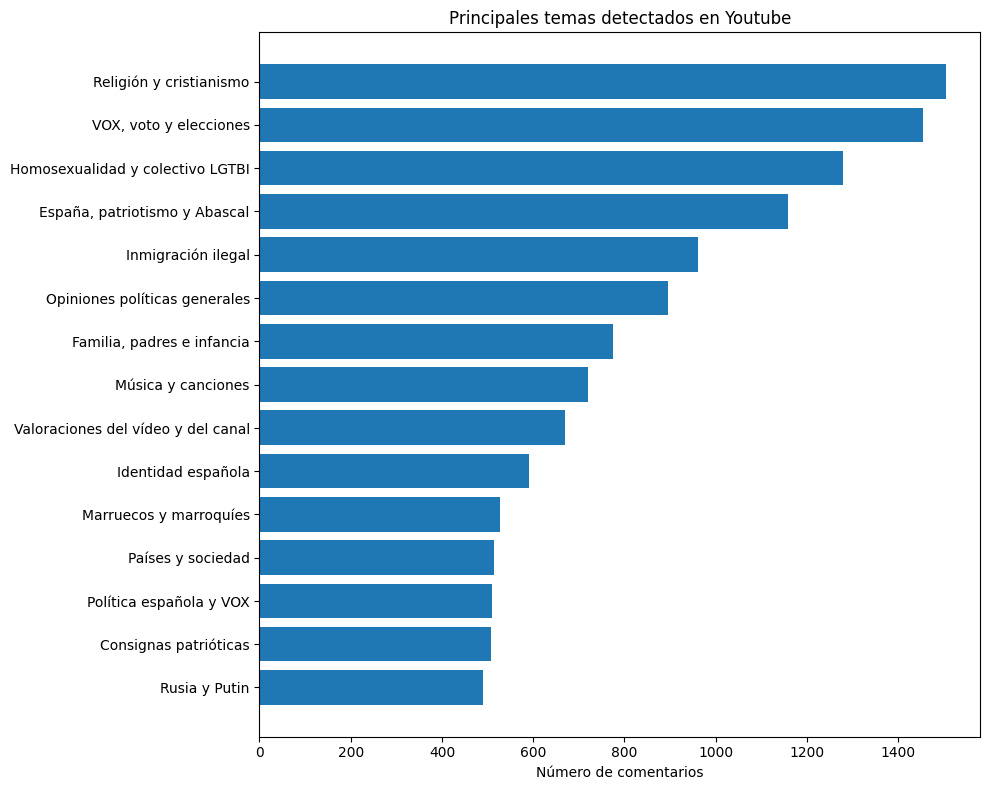

In [ ]:
# ============================
# TOP TEMAS INTERPRETABLES
# ============================

plt.figure(figsize=(10, 8))

plt.barh(
    top_temas_limpios["tema"],
    top_temas_limpios["Count"]
)

plt.title("Principales temas detectados en Youtube")
plt.xlabel("Número de comentarios")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    RUTA_GRAFICOS / "12_top_topics_interpretables.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()